# Imports

In [2]:
import os
import pickle
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, roc_curve

import matplotlib.pyplot as plt
from tqdm import tqdm


DATA_DIR = "/kaggle/input/datasets/gouravanirudh/fashion/processed"

# Load Data

In [3]:
with open(os.path.join(DATA_DIR, "train_labels.pkl"), "rb") as f:
    train_labels = pickle.load(f)

with open(os.path.join(DATA_DIR, "val_labels.pkl"), "rb") as f:
    val_labels = pickle.load(f)

with open(os.path.join(DATA_DIR, "class_weights.pkl"), "rb") as f:
    class_weights = pickle.load(f)

with open(os.path.join(DATA_DIR, "top5.pkl"), "rb") as f:
    top5_classes = pickle.load(f)

NUM_CLASSES = len(top5_classes)

print("Classes:", top5_classes)

Classes: [1, 8, 7, 2, 9]


# Class Balancing

In [4]:
label_matrix = np.array(list(train_labels.values()))

class_counts = label_matrix.sum(axis=0)

sampling_weights = 1.0 / (class_counts + 1e-6)

sample_weights = (label_matrix * sampling_weights).sum(axis=1)

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Dataset

In [5]:
class ApparelDataset(Dataset):

    def __init__(self, img_dir, labels_dict, transform=None):

        self.img_dir = img_dir
        self.labels = labels_dict
        self.transform = transform
        self.img_names = list(labels_dict.keys())

    def __len__(self):

        return len(self.img_names)

    def __getitem__(self, idx):

        img_name = self.img_names[idx]

        img_path = os.path.join(self.img_dir, "images", img_name)

        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(self.labels[img_name]).float()

        if self.transform:
            image = self.transform(image)

        return image, label

# Transforms

In [6]:
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


val_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# Datasets

In [7]:
train_dataset = ApparelDataset(
    os.path.join(DATA_DIR,"train"),
    train_labels,
    train_tfms
)

val_dataset = ApparelDataset(
    os.path.join(DATA_DIR,"validation"),
    val_labels,
    val_tfms
)

# DATALOADERS

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# MODEL

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.mobilenet_v3_large(weights=None)

model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    NUM_CLASSES
)

Device: cuda


# LOAD SCRATCH MODEL

In [10]:
model.load_state_dict(
    torch.load("/kaggle/input/datasets/arnavoruganty/scratch-model/best_model.pth")
)
model = model.to(device)

print("Loaded scratch-trained model")

Loaded scratch-trained model


# Freeze Backbone

In [11]:
for param in model.features.parameters():
    param.requires_grad = False

# LOSS + OPTIMIZER

In [12]:
class_weights = torch.tensor(class_weights).float().to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

# TRAIN FUNCTION

In [13]:
def train_epoch(loader):

    model.train()

    total_loss = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# EVALUATION

In [14]:
def evaluate(loader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs).cpu()

            preds.append(probs)
            targets.append(labels)

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()

    preds_bin = (preds > 0.5).astype(int)

    macro_f1 = f1_score(targets, preds_bin, average="macro", zero_division=0)
    micro_f1 = f1_score(targets, preds_bin, average="micro", zero_division=0)

    precision = precision_score(targets, preds_bin, average=None, zero_division=0)
    recall = recall_score(targets, preds_bin, average=None, zero_division=0)
    f1 = f1_score(targets, preds_bin, average=None, zero_division=0)

    auc_scores = []

    for i in range(NUM_CLASSES):

        try:
            auc = roc_auc_score(targets[:, i], preds[:, i])
        except:
            auc = 0

        auc_scores.append(auc)

    print("\nPer-class metrics:")

    for i, cls in enumerate(top5_classes):

        print(
            f"{cls}: Precision={precision[i]:.3f}, "
            f"Recall={recall[i]:.3f}, "
            f"F1={f1[i]:.3f}, "
            f"AUC={auc_scores[i]:.3f}"
        )

    print("\nMacro F1:", macro_f1)
    print("Micro F1:", micro_f1)

    return preds, targets, macro_f1

In [15]:
def plot_roc_curves(preds, targets):

    plt.figure(figsize=(8,6))

    for i, cls in enumerate(top5_classes):

        fpr, tpr, _ = roc_curve(targets[:, i], preds[:, i])

        auc = roc_auc_score(targets[:, i], preds[:, i])

        plt.plot(fpr, tpr, label=f"{cls} (AUC={auc:.2f})")

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves per Class")

    plt.legend()

    plt.show()

# FINE-TUNING LOOP

In [16]:
FINE_TUNE_EPOCHS = 5

best_f1 = 0

for epoch in range(FINE_TUNE_EPOCHS):

    train_loss = train_epoch(train_loader)

    preds, targets, val_f1 = evaluate(val_loader)

    print(f"\nFine-Tune Epoch {epoch+1}")
    print("Train Loss:", train_loss)
    print("Val Macro F1:", val_f1)

    if val_f1 > best_f1:

        best_f1 = val_f1

        torch.save(
            model.state_dict(),
            "/kaggle/working/mobilenet_finetuned.pth"
        )

100%|██████████| 4506/4506 [17:47<00:00,  4.22it/s]



Per-class metrics:
1: Precision=0.912, Recall=0.727, F1=0.809, AUC=0.922
8: Precision=0.909, Recall=0.819, F1=0.862, AUC=0.962
7: Precision=0.751, Recall=0.704, F1=0.727, AUC=0.931
2: Precision=0.706, Recall=0.689, F1=0.697, AUC=0.913
9: Precision=0.810, Recall=0.710, F1=0.757, AUC=0.934

Macro F1: 0.7703543304750318
Micro F1: 0.7861883582048191

Fine-Tune Epoch 1
Train Loss: 0.21302823439121404
Val Macro F1: 0.7703543304750318


100%|██████████| 4506/4506 [14:18<00:00,  5.25it/s]



Per-class metrics:
1: Precision=0.917, Recall=0.718, F1=0.805, AUC=0.923
8: Precision=0.916, Recall=0.804, F1=0.856, AUC=0.962
7: Precision=0.749, Recall=0.707, F1=0.728, AUC=0.931
2: Precision=0.715, Recall=0.678, F1=0.696, AUC=0.913
9: Precision=0.813, Recall=0.707, F1=0.756, AUC=0.934

Macro F1: 0.7682020600527049
Micro F1: 0.7833046976490802

Fine-Tune Epoch 2
Train Loss: 0.20958785616982475
Val Macro F1: 0.7682020600527049


100%|██████████| 4506/4506 [13:16<00:00,  5.66it/s]



Per-class metrics:
1: Precision=0.914, Recall=0.725, F1=0.808, AUC=0.923
8: Precision=0.916, Recall=0.804, F1=0.856, AUC=0.962
7: Precision=0.752, Recall=0.706, F1=0.728, AUC=0.932
2: Precision=0.718, Recall=0.670, F1=0.693, AUC=0.913
9: Precision=0.808, Recall=0.713, F1=0.758, AUC=0.934

Macro F1: 0.7687251293703381
Micro F1: 0.7842426102361656

Fine-Tune Epoch 3
Train Loss: 0.21038138960011524
Val Macro F1: 0.7687251293703381


100%|██████████| 4506/4506 [12:45<00:00,  5.89it/s]



Per-class metrics:
1: Precision=0.916, Recall=0.719, F1=0.806, AUC=0.923
8: Precision=0.912, Recall=0.813, F1=0.860, AUC=0.962
7: Precision=0.756, Recall=0.703, F1=0.728, AUC=0.931
2: Precision=0.712, Recall=0.681, F1=0.696, AUC=0.913
9: Precision=0.812, Recall=0.705, F1=0.755, AUC=0.934

Macro F1: 0.7688568957526747
Micro F1: 0.7842125808610305

Fine-Tune Epoch 4
Train Loss: 0.20967104807463002
Val Macro F1: 0.7688568957526747


100%|██████████| 4506/4506 [12:26<00:00,  6.04it/s]



Per-class metrics:
1: Precision=0.917, Recall=0.717, F1=0.805, AUC=0.923
8: Precision=0.916, Recall=0.804, F1=0.857, AUC=0.962
7: Precision=0.756, Recall=0.706, F1=0.730, AUC=0.932
2: Precision=0.713, Recall=0.681, F1=0.696, AUC=0.913
9: Precision=0.808, Recall=0.715, F1=0.759, AUC=0.934

Macro F1: 0.7693929538840193
Micro F1: 0.7840620553028823

Fine-Tune Epoch 5
Train Loss: 0.20938448571545043
Val Macro F1: 0.7693929538840193


# FINAL EVALUATION


Per-class metrics:
1: Precision=0.912, Recall=0.727, F1=0.809, AUC=0.922
8: Precision=0.909, Recall=0.819, F1=0.862, AUC=0.962
7: Precision=0.751, Recall=0.704, F1=0.727, AUC=0.931
2: Precision=0.706, Recall=0.689, F1=0.697, AUC=0.913
9: Precision=0.810, Recall=0.710, F1=0.757, AUC=0.934

Macro F1: 0.7703543304750318
Micro F1: 0.7861883582048191


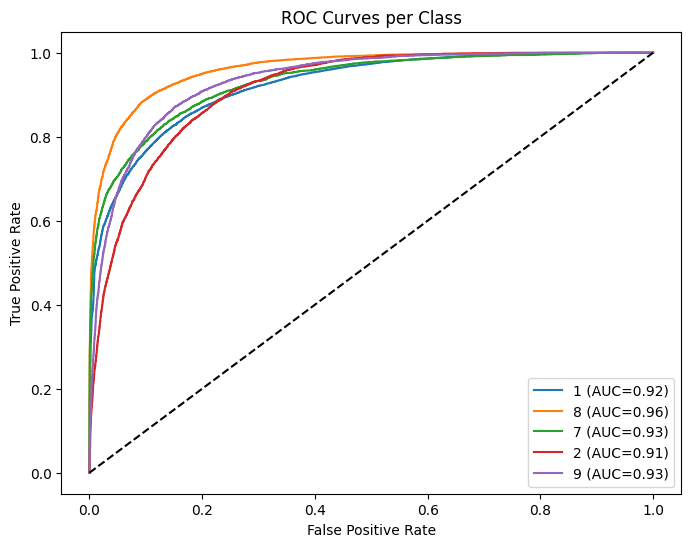

In [17]:
model.load_state_dict(
    torch.load("/kaggle/working/mobilenet_finetuned.pth")
)

preds, targets, _ = evaluate(val_loader)

plot_roc_curves(preds, targets)